The purpose of this notebook is to create a spectral cube that can be used as a `Source` for METIS IFU (a.k.a. LMS) simulations with Scopesim. The goal is not to create a realistic astrophysical source nor to probe any signal-to-noise limits, but to demonstrate the formal requirements on a FITS file that can be used by Scopesim, and maybe hint at some of the capabilities of the METIS IFU. 

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits
from astropy import units as u

The idea is to use an image of HL Tau (the ALMA image...) and turn it into a spectral cube with some rotation. 

In [2]:
import scopesim as sim

numexpr.utils - NumExpr defaulting to 8 threads.


In [3]:
path = sim.download_example_data("HL_Tau_prep_for_Scopesim.fits")

In [4]:
hdul = fits.open(path[0])

In [7]:
pixscale = np.abs(hdul[1].header['CDELT1'] * u.Unit(hdul[1].header['CUNIT1']))
pixscale.to(u.mas)

<Quantity 5. mas>

HL Tau is at a distance of 140 pc, but we will place it at 50 AU, which gives a scale of 20 mas per AU:

In [8]:
au_mas = 1000 * u.mas / 50 

We shall model the rotation of the disk as Keplerian with a reference rotational velocity of 30 km/s at 1 AU, which gives a velocity shift of 
$$\frac{\Delta\lambda}{\lambda} = \frac{v}{c} = 10^{-4} \left(\frac{R_\mathrm{ell}}{7.14\,\mathrm{mas}}\right)^{-1},$$
where $R_\mathrm{ell}$ is the projected radius in the disk onto the plane of the sky. The disk appears elliptical with $e = b/a\approx 0.75$ at a position angle of $\phi\approx 45^\circ$, so
$$R_\mathrm{ell} = \sqrt{ x'^2 + (y'/e)^2}$$
with
$$x' = x \cos\phi - y \sin\phi$$
$$y' = x\sin\phi + y \cos\phi$$

To implement this, we first cut the image to a size that is a little larger than the field of view of the image slicer of the METIS IFU, which is roughly $0.9\,\mathrm{arcsec}\times 0.6\,\mathrm{arcsec}$. The following numbers have been determined by inspection of the original image such that the disk is centred in the new image.

In [9]:
npix = int(0.9 / pixscale.to(u.arcsec).value)
npix

179

In [10]:
x1 = int(802.5 - npix / 2)
x2 = int(802.5 + npix / 2) + 1
y1 = int(839.5 - npix / 2)
y2 = int(839.5 + npix / 2) + 1
img_cut = hdul[1].data[y1:y2, x1:x2]

In [11]:
from astropy.wcs import WCS

In [12]:
wcs = WCS(hdul[1].header)

In [13]:
wcs.wcs.crpix = [89.5, 89.5]
wcs.wcs.crval = [0., 0.]
wcs.wcs.ctype = ["LINEAR", "LINEAR"]

In [14]:
hdul[1].data = img_cut
hdul[1].header.update(wcs.to_header())

In [15]:
hdul.writeto("HL_Tau_img_cut.fits", overwrite=True)

In [16]:
# Derive two images for the world coordinates from that
i, j = np.meshgrid(np.arange(npix), np.arange(npix))
x, y = wcs.all_pix2world(i, j, 0)
x = (x * u.Unit(wcs.wcs.cunit[0]) << u.mas).value 
y = (y * u.Unit(wcs.wcs.cunit[1]) << u.mas).value

In [17]:
phi = 45 * np.pi / 180
xx = x * np.cos(phi) - y * np.sin(phi)
yy = x * np.sin(phi) + y * np.cos(phi)

In [18]:
inc = 45 * np.pi / 180
ell = np.cos(inc)
R_ell = np.sqrt(xx**2 + (yy/ell)**2)

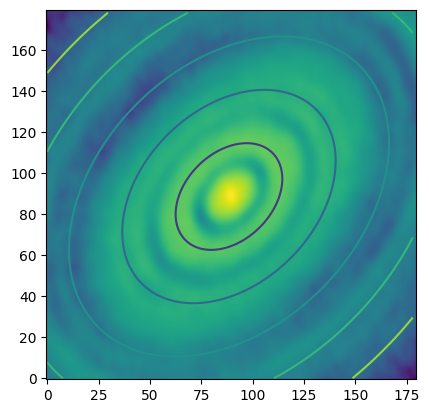

In [20]:
plt.imshow(hdul[1].data, origin='lower', norm='log')
plt.contour(R_ell);

In [21]:
v_los = 30 * xx * au_mas.value / R_ell**2 * np.sin(inc)
dloglambda = v_los / 2.998e6

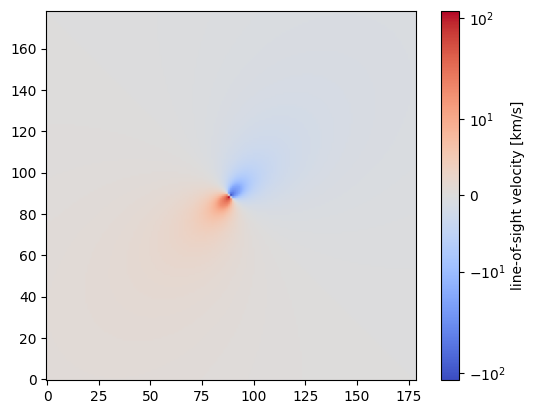

In [23]:
from matplotlib.colors import SymLogNorm
from matplotlib.cm import coolwarm
plt.imshow(v_los, norm=SymLogNorm(linthresh=13), cmap=coolwarm, origin='lower')
plt.colorbar(label="line-of-sight velocity [km/s]");

We choose a central wavelength of 3.5$\,\mu$m. The LMS covers a wavelength range from 3.472 to 3.526$\,\mu$m (these can be obtained from
`metis['lms_spectral_traces'].meta['wave_min']` and `metis['lms_spectral_traces'].meta['wave_max']`). 
A data cube used as `Source` for a Scopesim simulation should cover this wavelength range (a smaller range should work but fills the detector images only partially) at a wavelength sampling that is comparable to or better than the dispersion (in microns per pixel) on the LMS detectors.An indication is given by the scopesim parameter `!SIM.spectral.spectral_bin_width`, which is set to $10^{-5}\,\mu$m for the LMS (and should not be changed by the user). 

In [24]:
wave_min, wave_max = 3.472, 3.526   # microns
dwave = 1e-5                        
wavelength = np.arange(wave_min, wave_max, dwave)
wcs_cube = wcs.sub([1, 2, 0])   # extend image wcs to cube wcs
wcs_cube.wcs.ctype[2] = "WAVE"
wcs_cube.wcs.crpix[2] = 1
wcs_cube.wcs.crval[2] = wave_min
wcs_cube.wcs.cdelt[2] = dwave
wcs_cube.wcs.cunit[2] = "um"

In [25]:
flux = np.zeros_like(wavelength)
sigma = 1.5 * dwave
for lamc in [3.48, 3.49, 3.5, 3.51, 3.52]:
    flux += 0.2 * np.exp(-(wavelength - lamc)**2/(2 * sigma**2))
flux += 0.4 - ((wavelength - lamc)/0.3)**2

(0.0, 0.7)

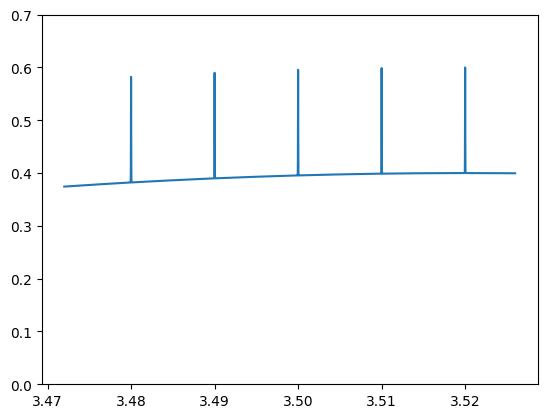

In [26]:
plt.plot(wavelength, flux)
plt.ylim(0, 0.7)

In [27]:
cube = np.outer(flux, img_cut)
cube = cube.reshape(5400, img_cut.shape[1], img_cut.shape[0])

To get a usable flux scaling we look at the minimum and maximum values in the cube:

In [28]:
print(cube.min(), cube.max())

2.0671206314659683e-09 6.77702860230056e-07


Real circumstellar disks have total fluxes of around 100 mJy (optimistically), so we need to scale our cube by about a factor of 50, let's make it 100: 

In [29]:
cube *= 100

In [30]:
total_spec = cube.sum(axis=(1, 2))

Text(0, 0.5, 'Jy')

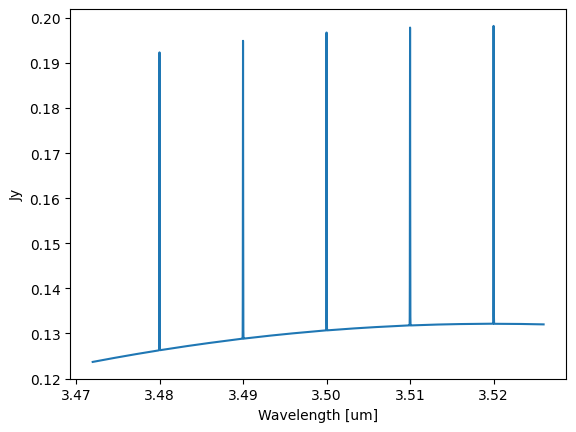

In [31]:
plt.plot(wavelength, total_spec)
plt.xlabel("Wavelength [um]")
plt.ylabel("Jy")

Build a fits file:

In [32]:
hdr = wcs_cube.to_header()
hdr['BUNIT'] = "Jy"

In [33]:
hdu_cube = fits.PrimaryHDU(header=hdr, data=cube.astype(np.float32))

In [34]:
hdu_cube.writeto("our_first_cube.fits", overwrite=True)

In the next notebook we will use this cube as the Source object for METIS-LMS observations.